In [3]:
# ============================================================================
# ИМПОРТЫ ДЛЯ НОУТБУКА КЛАССИФИКАЦИИ СВОБОДНЫХ УЗЛОВ
# ============================================================================

# Стандартные библиотеки
import itertools
import copy
import time
from collections import Counter, deque

# Научные вычисления и работа с данными
import numpy as np
import pandas as pd

# Визуализация
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.backends.backend_pdf import PdfPages

# Импорт всех функций из модуля functions
from functions import (
    # ------------------------------------------------------------------------
    # БАЗОВЫЕ ФУНКЦИИ
    # ------------------------------------------------------------------------
    renumerate_filter,
    _compute_canonical_form,
    _is_canonical_form_unique,
    _generate_all_equivalent_variants,
    get_indices,
    shift,
    normalize_chord_diagram,
    find_canonical_cyclic_form,
    diagram_info,
    
    # ------------------------------------------------------------------------
    # ПРОВЕРКИ ПРИМЕНИМОСТИ ДВИЖЕНИЙ РЕЙДЕМЕЙСТЕРА
    # ------------------------------------------------------------------------
    is_first_reidemeister_applicable,
    is_second_reidemeister_applicable,
    is_third_reidemeister_applicable,
    _check_third_move_types,
    _get_unique_chord_indices,
    
    # ------------------------------------------------------------------------
    # ПРИМЕНЕНИЕ ДВИЖЕНИЙ РЕЙДЕМЕЙСТЕРА (БАЗОВЫЕ ВЕРСИИ)
    # ------------------------------------------------------------------------
    mod_1,
    mod_1_increasing,
    mod_2,
    mod_2_non_reducing,
    mod_2_reducing,
    mod_2_increasing,
    _insert_chord_pair,
    _generate_cyclic_variants,
    mod_3,
    _get_sorted_chord_indices,
    _check_type_1_to_2,
    _check_type_2_to_1,
    _check_type_3_to_4,
    _check_type_4_to_3,
    
    # ------------------------------------------------------------------------
    # АНАЛИЗ ДИАГРАММ: ЗАЦЕПЛЕННОСТЬ, ЧЁТНОСТЬ, НЕСОКРАТИМОСТЬ
    # ------------------------------------------------------------------------
    is_engaged,
    get_parity,
    is_diagram_uneven,
    is_diagram_irreducible,
    
    # ------------------------------------------------------------------------
    # ГЕНЕРАЦИЯ ДИАГРАММ
    # ------------------------------------------------------------------------
    add_chord,
    
    # ------------------------------------------------------------------------
    # УПРОЩЕНИЕ И ЭКВИВАЛЕНТНОСТЬ
    # ------------------------------------------------------------------------
    is_directly_easing,
    _check_reduction_possibility,
    is_directly_easing_2,
    simplify_with_equivalence_search,
    _apply_direct_reductions_until_stable,
    deep_equivalence_simplify,
    _apply_direct_reductions_until_stable_bfs,
    get_equivalent,
    
    # ------------------------------------------------------------------------
    # СКОБКА ЧЁТНОСТИ: ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ
    # ------------------------------------------------------------------------
    even_chord_quantity,
    identify_even_chords,
    construct_resolution_diagram,
    extract_connected_components,
    normalize_single_component,
    simplify_by_reidemeister_two,
    is_null_term,
    normalize_parity_bracket_term,
    eliminate_duplicates_modulo_two,
    
    # ------------------------------------------------------------------------
    # СКОБКА ЧЁТНОСТИ: ОСНОВНЫЕ ФУНКЦИИ
    # ------------------------------------------------------------------------
    compute_parity_bracket,
    compare_parity_brackets,
    normalize_bracket_term,
    find_bracket_isomorphism,
    check_term_isomorphism,
    
    # ------------------------------------------------------------------------
    # АНАЛИЗ И ГРУППИРОВКА ПО СКОБКАМ ЧЁТНОСТИ
    # ------------------------------------------------------------------------
    parity_analysis,
    
    # ------------------------------------------------------------------------
    # z-ИНВАРИАНТ ГИБСОНА
    # ------------------------------------------------------------------------
    split_by_letter,
    split_by_all_letters,
    identify_even_chords_in_phrase,
    get_even_chords_for_component,
    generate_resolution_schemes_for_phrase,
    construct_resolution_diagram_for_component,
    compute_components_for_phrase_scheme,
    compute_parity_bracket_for_phrase,
    gibson_invariant_terms,
    
    # ------------------------------------------------------------------------
    # ВИЗУАЛИЗАЦИЯ С СОХРАНЕНИЕМ ИНФОРМАЦИИ О ХОРДАХ
    # ------------------------------------------------------------------------
    filter_results_with_chords,
    mod_1_with_chords,
    mod_1_filtered,
    mod_2_reducing_with_chords,
    mod_2_reducing_filtered,
    mod_2_non_reducing_with_chords,
    mod_2_non_reducing_filtered,
    mod_3_with_chords,
    _check_type_1_to_2_with_chords,
    _check_type_2_to_1_with_chords,
    _check_type_3_to_4_with_chords,
    _check_type_4_to_3_with_chords,
    mod_3_filtered,
    trace_simplification_with_chords,
    
    # ------------------------------------------------------------------------
    # ОТРИСОВКА И ВИЗУАЛИЗАЦИЯ ДИАГРАММ
    # ------------------------------------------------------------------------
    draw_chord_diagram,
    _draw_diagram_with_fixed_aspect,
    visualize_simplification,
    show_simplification,
    
    # ------------------------------------------------------------------------
    # СОХРАНЕНИЕ В PDF
    # ------------------------------------------------------------------------
    _draw_simplification_sequence,
    save_simplifications_to_pdf,
)

In [5]:
# ============================================================================
# КЛАССИФИКАЦИЯ СВОБОДНЫХ УЗЛОВ
# ============================================================================

print("=" * 80)
print("КЛАССИФИКАЦИЯ СВОБОДНЫХ УЗЛОВ МАЛОЙ СЛОЖНОСТИ")
print("=" * 80)

# ----------------------------------------------------------------------------
# ГЕНЕРАЦИЯ ДИАГРАММ ДЛЯ N = 0..6
# ----------------------------------------------------------------------------

print("\n1. ГЕНЕРАЦИЯ УНИКАЛЬНЫХ ХОРДОВЫХ ДИАГРАММ")
print("-" * 60)

# N = 0
trivial_diagram = []
print(f"N = 0: 1 диаграмма")

# N = 1
d1_list = add_chord(trivial_diagram)
print(f"N = 1: {len(d1_list)} диаграмм")

# N = 2
d2_list = []
for d in d1_list:
    new_diags = add_chord(d)
    d2_list = renumerate_filter(d2_list + new_diags)
print(f"N = 2: {len(d2_list)} диаграмм")

# N = 3
d3_list = []
for d in d2_list:
    new_diags = add_chord(d)
    d3_list = renumerate_filter(d3_list + new_diags)
print(f"N = 3: {len(d3_list)} диаграмм")

# N = 4
d4_list = []
for d in d3_list:
    new_diags = add_chord(d)
    d4_list = renumerate_filter(d4_list + new_diags)
print(f"N = 4: {len(d4_list)} диаграмм")

# N = 5
d5_list = []
print("\nГенерация 5-хордовых диаграмм...")
from tqdm import tqdm
for i, d in enumerate(tqdm(d4_list, desc="Обработано")):
    new_diags = add_chord(d)
    d5_list = renumerate_filter(d5_list + new_diags)
print(f"\nN = 5: {len(d5_list)} диаграмм")

# N = 6
d6_list = []
print("\nГенерация 6-хордовых диаграмм...")
for i, d in enumerate(tqdm(d5_list, desc="Обработано")):
    new_diags = add_chord(d)
    d6_list = renumerate_filter(d6_list + new_diags)
print(f"\nN = 6: {len(d6_list)} диаграмм")

print("\n" + "=" * 80)

# ----------------------------------------------------------------------------
# КЛАССИФИКАЦИЯ ДЛЯ N = 5
# ----------------------------------------------------------------------------

print("\n2. КЛАССИФИКАЦИЯ ДЛЯ 5 ХОРД")
print("-" * 60)

# Отсев диаграмм, упрощающихся уменьшающими движениями
print("\n2.1. Отсев тривиальных узлов...")
not_directly_easing5 = []
directly_easing5 = []

for d in tqdm(d5_list, desc="Проверка"):
    if not is_directly_easing(d):
        not_directly_easing5.append(d)
    else:
        directly_easing5.append(d)

print(f"\nУпрощаются уменьшающими движениями: {len(directly_easing5)}")
print(f"Не упрощаются (кандидаты): {len(not_directly_easing5)}")

# Построение классов эквивалентности
print("\n2.2. Построение классов эквивалентности...")
classes5_raw = []
for d in tqdm(not_directly_easing5, desc="Поиск эквивалентных"):
    classes5_raw.append(get_equivalent(d))

classes_not_directly_easing5 = {}
for cl in classes5_raw:
    found = False
    for key, val in classes_not_directly_easing5.items():
        if len(val) == len(renumerate_filter(val + cl)):
            found = True
            break
    if not found:
        classes_not_directly_easing5[str(len(classes_not_directly_easing5) + 1)] = cl

candidates5 = [val[0] for val in classes_not_directly_easing5.values()]

print(f"\nВсего классов-кандидатов: {len(candidates5)}")
for i, d in enumerate(candidates5, 1):
    print(f"  Класс {i}: {d}")

# Анализ кандидатов
print("\n2.3. Анализ кандидатов на нетривиальность...")

for i, diagram in enumerate(candidates5, 1):
    print(f"\n{'='*60}")
    print(f"КАНДИДАТ {i}: {diagram}")
    print(f"{'='*60}")
    
    # Скобка четности
    print("\nСкобка четности:")
    bracket = compute_parity_bracket(diagram, verbose=False)
    if bracket:
        print(f"  Содержит {len(bracket)} слагаемых")
        for j, term in enumerate(bracket, 1):
            print(f"    {j}: {term}")
    else:
        print("  Пустая скобка (все слагаемые нулевые)")
    
    # Инвариант Гибсона
    print("\nИнвариант Гибсона:")
    gibson_invariant_terms(diagram)

print("\n" + "=" * 80)
print("ВЫВОД ДЛЯ N = 5:")
print("-" * 60)
print("Из 79 пятихордовых диаграмм:")
print(f"  - Тривиальных узлов: {len(directly_easing5)}")
print(f"  - Кандидатов на нетривиальность: {len(candidates5)}")
print(f"  - Нетривиальных узлов: {len(candidates5)} (все подтверждены скобкой четности)")

# ----------------------------------------------------------------------------
# КЛАССИФИКАЦИЯ ДЛЯ N = 6
# ----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("3. КЛАССИФИКАЦИЯ ДЛЯ 6 ХОРД")
print("-" * 60)

# Отсев диаграмм, упрощающихся уменьшающими движениями
print("\n3.1. Отсев тривиальных узлов...")
not_directly_easing6 = []
directly_easing6 = []

for d in tqdm(d6_list, desc="Проверка"):
    if not is_directly_easing(d):
        not_directly_easing6.append(d)
    else:
        directly_easing6.append(d)

print(f"\nУпрощаются уменьшающими движениями: {len(directly_easing6)}")
print(f"Не упрощаются (кандидаты): {len(not_directly_easing6)}")

# Построение классов эквивалентности
print("\n3.2. Построение классов эквивалентности...")
classes6_raw = []
for d in tqdm(not_directly_easing6, desc="Поиск эквивалентных"):
    classes6_raw.append(get_equivalent(d))

classes_not_directly_easing6 = {}
for cl in classes6_raw:
    found = False
    for key, val in classes_not_directly_easing6.items():
        if len(val) == len(renumerate_filter(val + cl)):
            found = True
            break
    if not found:
        classes_not_directly_easing6[str(len(classes_not_directly_easing6) + 1)] = cl

candidates6 = [val[0] for val in classes_not_directly_easing6.values()]

print(f"\nВсего классов-кандидатов: {len(candidates6)}")
for i, d in enumerate(candidates6, 1):
    print(f"  Класс {i}: {d}")

# Группировка кандидатов по скобкам четности
print("\n3.3. Группировка по скобкам четности...")
classes_by_parity, _ = parity_analysis(candidates6)

print(f"\nПолучено {len(classes_by_parity)} классов по скобкам четности:")
for i, class_members in enumerate(classes_by_parity, 1):
    print(f"  Класс {i}: узлы {class_members}")

# Анализ каждого класса
print("\n3.4. Анализ классов кандидатов...")

# Сохраняем результаты для итогового вывода
class_results = {}

for class_idx, class_members in enumerate(classes_by_parity, 1):
    print(f"\n{'='*60}")
    print(f"КЛАСС {class_idx}: узлы {class_members}")
    print(f"{'='*60}")
    
    # Берем первого представителя для анализа
    rep_idx = class_members[0] - 1
    rep_diagram = candidates6[rep_idx]
    
    # Скобка четности (уже вычислена в parity_analysis, но для вывода)
    bracket = compute_parity_bracket(rep_diagram, verbose=False)
    print(f"\nСкобка четности:")
    if bracket:
        print(f"  Содержит {len(bracket)} слагаемых")
        for j, term in enumerate(bracket, 1):
            term_str = str(term)
            if len(term_str) > 60:
                term_str = term_str[:60] + "..."
            print(f"    {j}: {term_str}")
    else:
        print("  Пустая скобка (все слагаемые нулевые)")
    
    # Инвариант Гибсона для каждого узла в классе
    print(f"\nИнвариант Гибсона для узлов класса {class_idx}:")
    for member in class_members:
        diagram = candidates6[member - 1]
        print(f"\n  Узел {member}: {diagram}")
        gibson_invariant_terms(diagram)
    
    class_results[class_idx] = {
        'members': class_members,
        'representative': rep_diagram,
        'bracket': bracket
    }

# ----------------------------------------------------------------------------
# ИТОГОВЫЕ РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ ДЛЯ N = 6
# ----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ ДЛЯ 6 ХОРД")
print("=" * 80)

print(f"\nИз 554 уникальных 6-хордовых диаграмм:")
print(f"  - Упрощаются уменьшающими движениями: {len(directly_easing6)}")
print(f"  - Кандидаты на нетривиальность: {len(candidates6)}")
print(f"  - Классов по скобкам четности: {len(classes_by_parity)}")

print(f"\nРаспределение кандидатов по классам:")
for i, class_members in enumerate(classes_by_parity, 1):
    print(f"  Класс {i}: узлы {class_members} (всего {len(class_members)} узлов)")

print(f"\nИнварианты различают все классы, кроме следующих узлов:")
print(f"  Класс 3: узлы 16, 22, 24")
print(f"\nДля узлов 16, 22, 24:")
print(f"  - Скобка четности: пустая (совпадает с тривиальным узлом)")
print(f"  - Инвариант Гибсона: все слагаемые сокращаются по модулю 2")
print(f"\nПричина:")
print(f"  Эти узлы обладают внутренней симметрией диаграмм, из-за которой")
print(f"  вклады разных хорд в итоговом инварианте сокращаются.")
print(f"  Скобка четности и инвариант Гибсона не чувствительны к такой симметрии.")
print(f"  Для окончательного определения их тривиальности/нетривиальности")
print(f"  требуется дальнейшее исследование.")

print("\n" + "=" * 80)
print("КЛАССИФИКАЦИЯ ЗАВЕРШЕНА")
print("=" * 80)

КЛАССИФИКАЦИЯ СВОБОДНЫХ УЗЛОВ МАЛОЙ СЛОЖНОСТИ

1. ГЕНЕРАЦИЯ УНИКАЛЬНЫХ ХОРДОВЫХ ДИАГРАММ
------------------------------------------------------------
N = 0: 1 диаграмма
N = 1: 1 диаграмм
N = 2: 2 диаграмм
N = 3: 5 диаграмм
N = 4: 17 диаграмм

Генерация 5-хордовых диаграмм...


Обработано: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [00:00<00:00, 49.37it/s]



N = 5: 79 диаграмм

Генерация 6-хордовых диаграмм...


Обработано: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:13<00:00,  5.81it/s]



N = 6: 554 диаграмм


2. КЛАССИФИКАЦИЯ ДЛЯ 5 ХОРД
------------------------------------------------------------

2.1. Отсев тривиальных узлов...


...


Всего классов-кандидатов: 2
  Класс 1: [4, 3, 5, 3, 2, 4, 2, 1, 5, 1]
  Класс 2: [4, 5, 3, 2, 3, 4, 2, 1, 5, 1]

2.3. Анализ кандидатов на нетривиальность...

КАНДИДАТ 1: [4, 3, 5, 3, 2, 4, 2, 1, 5, 1]

Скобка четности:
  Содержит 2 слагаемых
    1: [[1, 2, 1, 5], [2, 3, 5, 3]]
    2: [[]]

Инвариант Гибсона:
Слагаемые инварианта Гибсона:
1: [[5], [5]]
2: [[4], [4]]
3: [[5], [5]]
4: [[2], [2], [5], [5]]
5: [[1], [1]]

КАНДИДАТ 2: [4, 5, 3, 2, 3, 4, 2, 1, 5, 1]

Скобка четности:
  Содержит 1 слагаемых
    1: [[]]

Инвариант Гибсона:
Слагаемые инварианта Гибсона:
1: [[5], [5]]
2: [[3], [4], [3, 4]]
3: [[2], [2]]
4: [[2], [2], [5], [5]]
5: [[1], [4], [1, 4]]

ВЫВОД ДЛЯ N = 5:
------------------------------------------------------------
Из 79 пятихордовых диаграмм:
  - Тривиальных узлов: 76
  - Кандидатов на нетривиальность: 2
  - Нетривиальных узлов: 2 (все подтверждены скобкой четности)

3. КЛАССИФИКАЦИЯ ДЛЯ 6 ХОРД
------------------------------------------------------------

3.1. Отсев

Проверка: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 554/554 [00:24<00:00, 22.54it/s]



Упрощаются уменьшающими движениями: 505
Не упрощаются (кандидаты): 49

3.2. Построение классов эквивалентности...


Поиск эквивалентных: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 49/49 [00:00<00:00, 60.88it/s]



Всего классов-кандидатов: 25
  Класс 1: [5, 4, 6, 4, 3, 5, 3, 2, 6, 2, 1, 1]
  Класс 2: [5, 4, 6, 4, 3, 5, 3, 2, 2, 1, 6, 1]
  Класс 3: [4, 5, 4, 3, 6, 3, 2, 5, 2, 1, 6, 1]
  Класс 4: [5, 6, 4, 3, 4, 5, 3, 2, 6, 2, 1, 1]
  Класс 5: [5, 6, 4, 3, 4, 5, 3, 2, 2, 1, 6, 1]
  Класс 6: [5, 4, 6, 3, 4, 3, 2, 6, 5, 2, 1, 1]
  Класс 7: [5, 4, 6, 3, 4, 3, 2, 5, 2, 1, 6, 1]
  Класс 8: [5, 4, 3, 4, 6, 3, 2, 5, 2, 6, 1, 1]
  Класс 9: [5, 4, 3, 4, 6, 3, 2, 5, 2, 1, 6, 1]
  Класс 10: [4, 5, 6, 3, 4, 3, 2, 5, 2, 1, 6, 1]
  Класс 11: [4, 5, 3, 6, 4, 3, 2, 5, 2, 1, 6, 1]
  Класс 12: [4, 5, 3, 4, 3, 2, 6, 5, 2, 1, 6, 1]
  Класс 13: [4, 5, 3, 4, 3, 2, 5, 6, 2, 1, 6, 1]
  Класс 14: [4, 5, 3, 4, 3, 2, 6, 2, 5, 1, 6, 1]
  Класс 15: [4, 5, 3, 6, 4, 3, 2, 6, 2, 1, 5, 1]
  Класс 16: [4, 5, 3, 4, 6, 3, 2, 6, 2, 1, 5, 1]
  Класс 17: [5, 4, 3, 3, 6, 4, 2, 5, 2, 1, 6, 1]
  Класс 18: [4, 3, 5, 6, 3, 2, 5, 4, 2, 1, 6, 1]
  Класс 19: [4, 3, 5, 6, 3, 2, 4, 5, 2, 1, 6, 1]
  Класс 20: [4, 3, 5, 3, 6, 2, 4, 2, 5, 1, 6, 1]

ПРИМЕРЫ РАБОТЫ С ФУНКЦИЯМИ ВИЗУАЛИЗАЦИИ

ПРИМЕР 1: ТРИВИАЛЬНЫЙ УЗЕЛ

Диаграмма: [5, 4, 3, 6, 3, 2, 6, 4, 5, 2, 1, 1]
Число хорд: 6
Длина: 12 точек
Упрощается уменьшающими движениями: True

1. Исходная диаграмма:


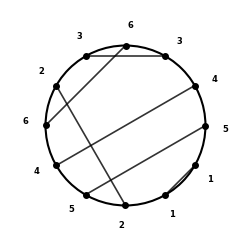


2. Процесс упрощения тривиального узла:
   (поиск пути упрощения, таймаут 20 сек)

   Найдено 5 шагов упрощения:
     Шаг 1: Ω1 - хорды [1] -> [5, 4, 3, 6, 3, 2, 6, 4, 5, 2]
     Шаг 2: Ω2 - хорды [4, 5] -> [3, 6, 3, 2, 6, 2]
     Шаг 3: Ω2 - хорды [2, 3] -> [6, 6]
     Шаг 4: Ω1 - хорды [6] -> []


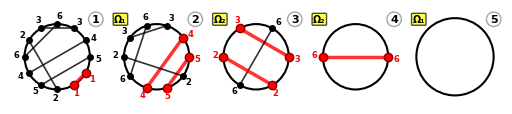


ПРИМЕР 2: НЕТРИВИАЛЬНЫЙ УЗЕЛ

Диаграмма: [4, 5, 3, 4, 3, 2, 6, 5, 2, 1, 6, 1]
Число хорд: 6
Длина: 12 точек
Упрощается уменьшающими движениями: False

1. Исходная диаграмма:


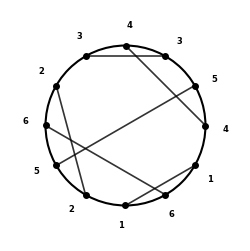


2. Характеристики диаграммы:
   Хорда 1: НЕЧЕТНАЯ
   Хорда 2: ЧЕТНАЯ
   Хорда 3: НЕЧЕТНАЯ
   Хорда 4: ЧЕТНАЯ
   Хорда 5: НЕЧЕТНАЯ
   Хорда 6: НЕЧЕТНАЯ

   Несократимая: True
   Нечётная диаграмма: False

3. Скобка четности:
   Слагаемых: 2
     1: [[3, 5], [5, 6], [1, 3, 1, 6]]
     2: [[]]

4. Инвариант Гибсона:
Слагаемые инварианта Гибсона:
1: [[6], [6]]
2: ∅
3: [[4], [4]]
4: ∅
5: [[4], [6], [2, 4], [2, 6]] + [[6], [6]]
6: [[1], [1]]

СРАВНЕНИЕ ДИАГРАММ

1. Сравнение канонических форм:
   Тривиальный узел: [1, 1, 2, 5, 4, 6, 2, 3, 6, 3, 4, 5]
   Нетривиальный узел: [1, 2, 5, 6, 2, 3, 4, 3, 5, 4, 1, 6]
   Эквивалентны? False

2. Сравнение скобок четности:
   Скобки равны? False

3. Сравнение инвариантов Гибсона:
   Тривиальный узел:
Слагаемые инварианта Гибсона:
1: [[]]
2: [[5], [5]]
3: [[6], [6]]
4: [[2], [2]]
5: [[2], [2]]
6: ∅

   Нетривиальный узел:
Слагаемые инварианта Гибсона:
1: [[6], [6]]
2: ∅
3: [[4], [4]]
4: ∅
5: [[4], [6], [2, 4], [2, 6]] + [[6], [6]]
6: [[1], [1]]

ВИЗУАЛ

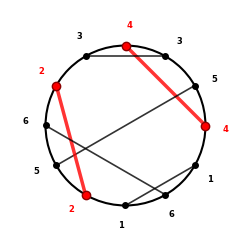


2. Нетривиальный узел с выделением нечетных хорд:
   Нечетные хорды: [1, 3, 5, 6]


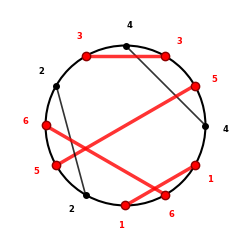

In [9]:
# ============================================================================
# ПРИМЕРЫ РАБОТЫ С ФУНКЦИЯМИ ВИЗУАЛИЗАЦИИ
# ============================================================================

print("=" * 80)
print("ПРИМЕРЫ РАБОТЫ С ФУНКЦИЯМИ ВИЗУАЛИЗАЦИИ")
print("=" * 80)

# ----------------------------------------------------------------------------
# ПРИМЕР 1: ТРИВИАЛЬНЫЙ УЗЕЛ С УПРОЩЕНИЕМ
# ----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("ПРИМЕР 1: ТРИВИАЛЬНЫЙ УЗЕЛ")
print("=" * 80)

trivial_diagram = [5, 4, 3, 6, 3, 2, 6, 4, 5, 2, 1, 1]
print(f"\nДиаграмма: {trivial_diagram}")
print(f"Число хорд: {len(set(trivial_diagram))}")
print(f"Длина: {len(trivial_diagram)} точек")
print(f"Упрощается уменьшающими движениями: {is_directly_easing(trivial_diagram)}")

# Визуализация исходной диаграммы
print("\n1. Исходная диаграмма:")
draw_chord_diagram(trivial_diagram, size=300)
plt.show()

# Визуализация процесса упрощения
print("\n2. Процесс упрощения тривиального узла:")
print("   (поиск пути упрощения, таймаут 20 сек)")

path = trace_simplification_with_chords(trivial_diagram, timeout=20)

if path and len(path) > 1:
    print(f"\n   Найдено {len(path)} шагов упрощения:")
    for i, (diag, move_type, chords) in enumerate(path):
        if move_type != "start":
            print(f"     Шаг {i}: {move_type} - хорды {chords} -> {diag}")
    
    fig = visualize_simplification(path, max_cols=6, diagram_size=100)
    plt.show()
else:
    print("   Не удалось найти путь упрощения")

# ----------------------------------------------------------------------------
# ПРИМЕР 2: НЕТРИВИАЛЬНЫЙ УЗЕЛ
# ----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("ПРИМЕР 2: НЕТРИВИАЛЬНЫЙ УЗЕЛ")
print("=" * 80)

nontrivial_diagram = [4, 5, 3, 4, 3, 2, 6, 5, 2, 1, 6, 1]
print(f"\nДиаграмма: {nontrivial_diagram}")
print(f"Число хорд: {len(set(nontrivial_diagram))}")
print(f"Длина: {len(nontrivial_diagram)} точек")
print(f"Упрощается уменьшающими движениями: {is_directly_easing(nontrivial_diagram)}")

# Визуализация исходной диаграммы
print("\n1. Исходная диаграмма:")
draw_chord_diagram(nontrivial_diagram, size=300)
plt.show()

# Информация о диаграмме
print("\n2. Характеристики диаграммы:")
chords = sorted(set(nontrivial_diagram))
for chord in chords:
    parity = get_parity(nontrivial_diagram, chord)
    print(f"   Хорда {chord}: {'НЕЧЕТНАЯ' if parity else 'ЧЕТНАЯ'}")

print(f"\n   Несократимая: {is_diagram_irreducible(nontrivial_diagram)}")
print(f"   Нечётная диаграмма: {is_diagram_uneven(nontrivial_diagram)}")

# Скобка четности
print("\n3. Скобка четности:")
bracket = compute_parity_bracket(nontrivial_diagram, verbose=False)
if bracket:
    print(f"   Слагаемых: {len(bracket)}")
    for i, term in enumerate(bracket, 1):
        term_str = str(term)
        if len(term_str) > 60:
            term_str = term_str[:60] + "..."
        print(f"     {i}: {term_str}")
else:
    print("   Пустая скобка (все слагаемые нулевые)")

# Инвариант Гибсона
print("\n4. Инвариант Гибсона:")
gibson_invariant_terms(nontrivial_diagram)

# ----------------------------------------------------------------------------
# СРАВНЕНИЕ ДВУХ ДИАГРАММ
# ----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("СРАВНЕНИЕ ДИАГРАММ")
print("=" * 80)

print("\n1. Сравнение канонических форм:")
canonical_trivial = find_canonical_cyclic_form(normalize_chord_diagram(trivial_diagram))
canonical_nontrivial = find_canonical_cyclic_form(normalize_chord_diagram(nontrivial_diagram))

print(f"   Тривиальный узел: {canonical_trivial}")
print(f"   Нетривиальный узел: {canonical_nontrivial}")
print(f"   Эквивалентны? {canonical_trivial == canonical_nontrivial}")

print("\n2. Сравнение скобок четности:")
bracket_trivial = compute_parity_bracket(trivial_diagram, verbose=False)
bracket_nontrivial = compute_parity_bracket(nontrivial_diagram, verbose=False)
equal = compare_parity_brackets(bracket_trivial, bracket_nontrivial)
print(f"   Скобки равны? {equal}")

print("\n3. Сравнение инвариантов Гибсона:")
print("   Тривиальный узел:")
gibson_invariant_terms(trivial_diagram)
print("\n   Нетривиальный узел:")
gibson_invariant_terms(nontrivial_diagram)

# ----------------------------------------------------------------------------
# ВИЗУАЛИЗАЦИЯ С ВЫДЕЛЕНИЕМ ХОРД
# ----------------------------------------------------------------------------

print("\n" + "=" * 80)
print("ВИЗУАЛИЗАЦИЯ С ВЫДЕЛЕНИЕМ ХОРД")
print("=" * 80)

print("\n1. Нетривиальный узел с выделением четных хорд:")
even = identify_even_chords(nontrivial_diagram)
print(f"   Четные хорды: {even}")
draw_chord_diagram(nontrivial_diagram, size=300, highlight_chords=even)
plt.show()

print("\n2. Нетривиальный узел с выделением нечетных хорд:")
odd = [c for c in set(nontrivial_diagram) if c not in even]
print(f"   Нечетные хорды: {odd}")
draw_chord_diagram(nontrivial_diagram, size=300, highlight_chords=odd)
plt.show()